# Análisis Exploratorio de Datos (EDA)
## Dataset: `bnf.src_reembolso_medico_diario desde 2022 pseudonimizado`

**Objetivo:** Entender el comportamiento del dataset de reembolsos médicos diarios de BNF desde 2022, identificando patrones, distribuciones, anomalías y relaciones entre variables.

---

## 1. Importación de Librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 60)
pd.set_option('display.float_format', '{:,.4f}'.format)

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 11
sns.set_theme(style='whitegrid', palette='muted')

print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


## 2. Carga del Dataset

In [2]:
FILE_PATH = 'bnf.src_reembolso_medico_diario desde 2022 pseudonimizado.csv'

df = pd.read_csv(
    FILE_PATH,
    sep=';',
    encoding='utf-8',
    low_memory=False,
    parse_dates=['FECHA_BONO', 'FECHA_MOVIMIENTO']
)

print(f'Dataset cargado exitosamente.')
print(f'  Filas:    {df.shape[0]:,}')
print(f'  Columnas: {df.shape[1]}')

Dataset cargado exitosamente.
  Filas:    928,971
  Columnas: 30


## 3. Vista General del Dataset

In [3]:
print('=== Primeras 5 filas ===')
df.head()

=== Primeras 5 filas ===


,PERIODO,FOLIO_REEMBOLSO,FOLIO_BONO,FECHA_BONO,NOMBRE_PRESTADOR,ID_TIPO_AFILIADO,DSC_TIPO_AFILIADO,ID_AGENCIA_USUARIO,DSC_AGENCIA_USUARIO,CUENTA_USUARIO,FOLIO_CAJA,ID_ESTADO_PAGO,DSC_ESTADO_PAGO,ID_ESTADO_CAJA,DSC_ESTADO_CAJA,FECHA_MOVIMIENTO,TOTAL_BONIFICADO_PESOS,TOTAL_BONIFICADO_UF,ESP_G1,ESP_G2,ESP_G3,ESP_DESCRIPCION,MONTO_BONIFICADO_PESOS,MONTO_BONIFICADO_UF,COPAGO_REEMBOLSO,COPAGO_REAL,ID_PREVISION,DSC_PREVISION,ID_EMP,ID_AFI
0,202212,31,841518387,2022-12-20,CENTRO DE SALUD 18 DE SEPTIEMBRE S.A.,2,Pensionado,520,Valparaiso,sayala,5200049058001556759,1,Ingresada,2,pendiente,2022-12-20 12:28:05,5850,0.1672,1,1,1,CONSULTA MEDICINA GENERAL,5850,0.1672,6750,6750,1,Fonasa,EMP_00012356,AFI_01042206
1,202305,3,4358583,2023-04-26,Operador_FF.AA.,2,Pensionado,1030,Pto. Montt,yvera,10300049058001579753,1,Ingresada,2,pendiente,2023-05-22 10:32:35,88143,2.4483,3,5,99,"PEPTIDO CICLICO CITRULINADO, ANTICUERPOS IGG",5305,0.1474,8843,8843,4,FF.AA.,EMP_00010000,AFI_01089557
2,202404,7,885196030,2024-03-25,CLINICA VIDASALUD,1,Activo,525,Los Andes,sespinola,1399004901044136,5,Cancelado,3,Cancelado en Caja,2024-04-12 10:16:04,24753,0.6659,1,1,310,CONSULTA MEDICA DE ESPECIALIDAD EN TRAUMATOLOGIA Y ORTOP...,3505,0.0943,7010,7010,1,Fonasa,EMP_00007605,AFI_00493003
3,202310,32,868323735,2023-10-02,Integramedica Centro Medica S.A.,1,Activo,510,Viña del Mar,lgarcia,1399004901016115,5,Cancelado,3,Cancelado en Caja,2023-10-03 10:37:36,3505,0.0968,1,1,308,CONSULTA MEDICA DE ESPECIALIDAD EN OBSTETRICIA Y GINECOL...,3505,0.0968,7010,7010,1,Fonasa,EMP_00022460,AFI_01456112
4,202501,12,912521194,2024-12-03,Integramedica Centro Medica S.A.,2,Pensionado,1311,San Bernardo,cnunezp,1399004901093561,5,Cancelado,3,Cancelado en Caja,2025-01-15 15:40:56,23707,0.6170,1,1,305,CONSULTA MEDICA DE ESPECIALIDAD EN MEDICINA FAMILIAR,3625,0.0943,7250,7250,1,Fonasa,EMP_00018723,AFI_01157772


In [4]:
print('=== Últimas 5 filas ===')
df.tail()

=== Últimas 5 filas ===


,PERIODO,FOLIO_REEMBOLSO,FOLIO_BONO,FECHA_BONO,NOMBRE_PRESTADOR,ID_TIPO_AFILIADO,DSC_TIPO_AFILIADO,ID_AGENCIA_USUARIO,DSC_AGENCIA_USUARIO,CUENTA_USUARIO,FOLIO_CAJA,ID_ESTADO_PAGO,DSC_ESTADO_PAGO,ID_ESTADO_CAJA,DSC_ESTADO_CAJA,FECHA_MOVIMIENTO,TOTAL_BONIFICADO_PESOS,TOTAL_BONIFICADO_UF,ESP_G1,ESP_G2,ESP_G3,ESP_DESCRIPCION,MONTO_BONIFICADO_PESOS,MONTO_BONIFICADO_UF,COPAGO_REEMBOLSO,COPAGO_REAL,ID_PREVISION,DSC_PREVISION,ID_EMP,ID_AFI
928966,202510,16,947819100,2025-10-06,Centro Clinico Aconcagua,1,Activo,525,Los Andes,mmolinaa,1399004901149613,5,Cancelado,3,Cancelado en Caja,2025-10-22 09:28:26,24585,0.6216,17,1,6,"E.C.G. CONTINUO (TEST HOLTER O SIMILARES, POR EJ.",8433,0.2132,28110,28110,1,Fonasa,EMP_00012459,AFI_01411820
928967,202510,16,948431811,2025-10-10,Centro Clinico Aconcagua,1,Activo,525,Los Andes,mmolinaa,1399004901149613,5,Cancelado,3,Cancelado en Caja,2025-10-22 09:28:26,24585,0.6216,4,1,10,MAMOGRAFIA BILATERAL (4 EXP.),7617,0.1926,25390,25390,1,Fonasa,EMP_00012459,AFI_01411820
928968,202510,16,948431811,2025-10-10,Centro Clinico Aconcagua,1,Activo,525,Los Andes,mmolinaa,1399004901149613,5,Cancelado,3,Cancelado en Caja,2025-10-22 09:28:26,24585,0.6216,4,4,12,ECOGRAFIA MAMARIA BILATERAL (INCLUYE DOPPLER),6231,0.1575,20770,20770,1,Fonasa,EMP_00012459,AFI_01411820
928969,202511,8,952551332,2025-11-11,Imagensalud,1,Activo,630,San Fernando,mmtorres,1399004901153534,5,Cancelado,3,Cancelado en Caja,2025-11-11 11:45:20,15780,0.3981,1,1,311,CONSULTA MEDICA DE ESPECIALIDAD EN UROLOGIA,15780,0.3981,16770,16770,1,Fonasa,EMP_00020097,AFI_01412167
928970,202510,3,947886882,2025-10-06,Centro Clinico Aconcagua,1,Activo,525,Los Andes,sespinola,1399004901151178,5,Cancelado,3,Cancelado en Caja,2025-10-28 13:12:34,17886,0.4519,6,1,101,EVALUACION KINESIOLOGICA INTEGRAL,543,0.0137,1810,1810,1,Fonasa,EMP_00030150,AFI_00648744


In [5]:
print('=== Tipos de datos y valores no nulos ===')
df.info(verbose=True, show_counts=True)

=== Tipos de datos y valores no nulos ===
<class 'pandas.DataFrame'>
RangeIndex: 928971 entries, 0 to 928970
Data columns (total 30 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   PERIODO                 928971 non-null  int64         
 1   FOLIO_REEMBOLSO         928971 non-null  int64         
 2   FOLIO_BONO              928971 non-null  int64         
 3   FECHA_BONO              928971 non-null  datetime64[us]
 4   NOMBRE_PRESTADOR        928971 non-null  str           
 5   ID_TIPO_AFILIADO        928971 non-null  int64         
 6   DSC_TIPO_AFILIADO       928971 non-null  str           
 7   ID_AGENCIA_USUARIO      928971 non-null  int64         
 8   DSC_AGENCIA_USUARIO     928971 non-null  str           
 9   CUENTA_USUARIO          928971 non-null  str           
 10  FOLIO_CAJA              928971 non-null  uint64        
 11  ID_ESTADO_PAGO          928971 non-null  int64         
 12 

In [6]:
# Clasificación de columnas por tipo
col_numericas   = df.select_dtypes(include=['number']).columns.tolist()
col_categoricas = df.select_dtypes(include=['object', 'category']).columns.tolist()
col_fechas      = df.select_dtypes(include=['datetime']).columns.tolist()

print(f'Columnas numéricas   ({len(col_numericas)}): {col_numericas}')
print(f'Columnas categóricas ({len(col_categoricas)}): {col_categoricas}')
print(f'Columnas de fechas   ({len(col_fechas)}): {col_fechas}')

Columnas numéricas   (18): ['PERIODO', 'FOLIO_REEMBOLSO', 'FOLIO_BONO', 'ID_TIPO_AFILIADO', 'ID_AGENCIA_USUARIO', 'FOLIO_CAJA', 'ID_ESTADO_PAGO', 'ID_ESTADO_CAJA', 'TOTAL_BONIFICADO_PESOS', 'TOTAL_BONIFICADO_UF', 'ESP_G1', 'ESP_G2', 'ESP_G3', 'MONTO_BONIFICADO_PESOS', 'MONTO_BONIFICADO_UF', 'COPAGO_REEMBOLSO', 'COPAGO_REAL', 'ID_PREVISION']
Columnas categóricas (10): ['NOMBRE_PRESTADOR', 'DSC_TIPO_AFILIADO', 'DSC_AGENCIA_USUARIO', 'CUENTA_USUARIO', 'DSC_ESTADO_PAGO', 'DSC_ESTADO_CAJA', 'ESP_DESCRIPCION', 'DSC_PREVISION', 'ID_EMP', 'ID_AFI']
Columnas de fechas   (2): ['FECHA_BONO', 'FECHA_MOVIMIENTO']


## 4. Análisis de Valores Nulos

In [7]:
nulos = pd.DataFrame({
    'Nulos': df.isnull().sum(),
    'Porcentaje (%)': (df.isnull().sum() / len(df) * 100).round(2)
}).sort_values('Nulos', ascending=False)

print('=== Valores Nulos por Columna ===')
display(nulos[nulos['Nulos'] > 0])
print(f'\nColumnas sin valores nulos: {(nulos["Nulos"] == 0).sum()} de {len(df.columns)}')

=== Valores Nulos por Columna ===


,Nulos,Porcentaje (%)
ID_EMP,1,0.0000



Columnas sin valores nulos: 29 de 30


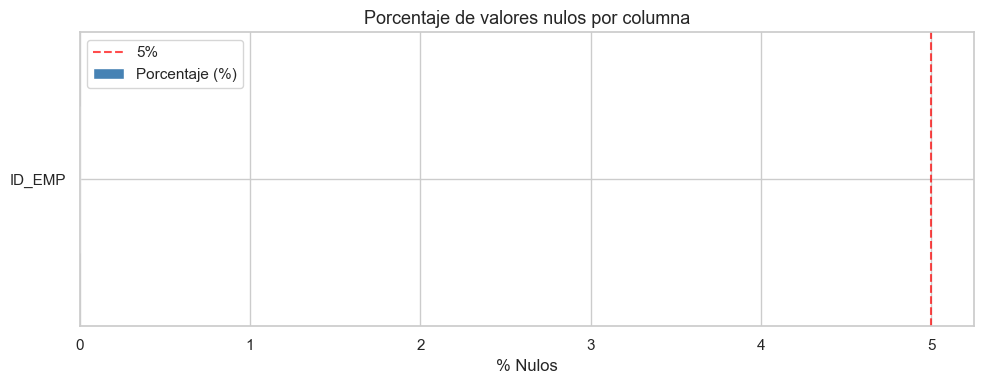

In [8]:
if nulos['Nulos'].sum() > 0:
    cols_con_nulos = nulos[nulos['Nulos'] > 0].index.tolist()
    fig, ax = plt.subplots(figsize=(10, max(4, len(cols_con_nulos) * 0.5)))
    nulos.loc[cols_con_nulos, 'Porcentaje (%)'].sort_values().plot(
        kind='barh', ax=ax, color='steelblue', edgecolor='white'
    )
    ax.set_title('Porcentaje de valores nulos por columna', fontsize=13)
    ax.set_xlabel('% Nulos')
    ax.axvline(5, color='red', linestyle='--', alpha=0.7, label='5%')
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print('No hay valores nulos en el dataset.')

## 5. Estadísticas Descriptivas

In [9]:
print('=== Variables Numéricas - Estadísticas Descriptivas ===')
df[col_numericas].describe().T.style.background_gradient(cmap='Blues', subset=['mean', 'std', '50%'])

=== Variables Numéricas - Estadísticas Descriptivas ===


,count,mean,std,min,25%,50%,75%,max
PERIODO,928971.000000,202397.896937,125.194897,202201.000000,202305.000000,202407.000000,202506.000000,202604.000000
FOLIO_REEMBOLSO,928971.000000,11.868215,15.884875,1.000000,2.000000,6.000000,15.000000,275.000000
FOLIO_BONO,928971.000000,2177242250.727888,212235596502.242950,5.000000,800420908.000000,884756935.000000,928823624.500000,47200000000000.000000
ID_TIPO_AFILIADO,928971.000000,1.663366,0.697022,1.000000,1.000000,2.000000,2.000000,4.000000
ID_AGENCIA_USUARIO,928971.000000,761.670716,343.213746,110.000000,520.000000,526.000000,1010.000000,1349.000000
FOLIO_CAJA,928971.000000,1998704216134366464.000000,3705395871425345536.000000,0.000000,1399004901036313.500000,1399004901107724.000000,5100049058001529856.000000,13490049058001582080.000000
ID_ESTADO_PAGO,928971.000000,2.972639,1.999814,1.000000,1.000000,1.000000,5.000000,5.000000
ID_ESTADO_CAJA,928971.000000,2.503528,0.499988,2.000000,2.000000,3.000000,3.000000,3.000000
TOTAL_BONIFICADO_PESOS,928971.000000,27352.827431,21223.504195,37.000000,11163.000000,22098.000000,38176.000000,119843.000000
TOTAL_BONIFICADO_UF,928971.000000,0.736104,0.565605,0.001070,0.303650,0.600360,1.028030,3.000070


In [10]:
# Estadísticas adicionales: skewness y kurtosis
stats_extra = pd.DataFrame({
    'Skewness': df[col_numericas].skew(),
    'Kurtosis': df[col_numericas].kurt(),
    'Ceros': (df[col_numericas] == 0).sum(),
    'Negativos': (df[col_numericas] < 0).sum()
})
print('=== Asimetría, Curtosis, Ceros y Negativos ===')
display(stats_extra)

=== Asimetría, Curtosis, Ceros y Negativos ===


,Skewness,Kurtosis,Ceros,Negativos
PERIODO,-0.1244,-1.1092,0,0
FOLIO_REEMBOLSO,3.1762,17.8813,0,0
FOLIO_BONO,171.9532,"30,571.5886",0,0
ID_TIPO_AFILIADO,0.9596,1.0635,0,0
ID_AGENCIA_USUARIO,0.7451,-0.9000,0,0
FOLIO_CAJA,1.8314,2.4250,52990,0
ID_ESTADO_PAGO,0.0274,-1.9993,0,0
ID_ESTADO_CAJA,-0.0141,-1.9998,0,0
TOTAL_BONIFICADO_PESOS,1.3533,2.0959,0,0
TOTAL_BONIFICADO_UF,1.3265,1.9938,0,0


## 6. Análisis de Variables Categóricas

In [11]:
print('=== Cardinalidad de Variables Categóricas ===')
cardinalidad = pd.DataFrame({
    'Valores únicos': df[col_categoricas].nunique(),
    'Valor más frecuente': [df[c].mode()[0] if not df[c].mode().empty else 'N/A' for c in col_categoricas],
    'Frecuencia moda': [df[c].value_counts().iloc[0] if not df[c].value_counts().empty else 0 for c in col_categoricas],
    '% Moda': [(df[c].value_counts().iloc[0] / len(df) * 100).round(2) if not df[c].value_counts().empty else 0 for c in col_categoricas]
}).sort_values('Valores únicos', ascending=False)
display(cardinalidad)

=== Cardinalidad de Variables Categóricas ===


,Valores únicos,Valor más frecuente,Frecuencia moda,% Moda
ID_AFI,66954,AFI_01040991,407,0.0400
ID_EMP,4453,EMP_00010185,112817,12.1400
ESP_DESCRIPCION,525,CONSULTA MEDICINA GENERAL,106513,11.4700
CUENTA_USUARIO,485,jaraya,26418,2.8400
NOMBRE_PRESTADOR,165,Integramedica Centro Medica S.A.,99279,10.6900
DSC_AGENCIA_USUARIO,43,Valparaiso,134236,14.4500
DSC_TIPO_AFILIADO,4,Pensionado,434051,46.7200
DSC_PREVISION,4,Fonasa,635266,68.3800
DSC_ESTADO_CAJA,2,Cancelado en Caja,467763,50.3500
DSC_ESTADO_PAGO,2,Ingresada,470840,50.6800


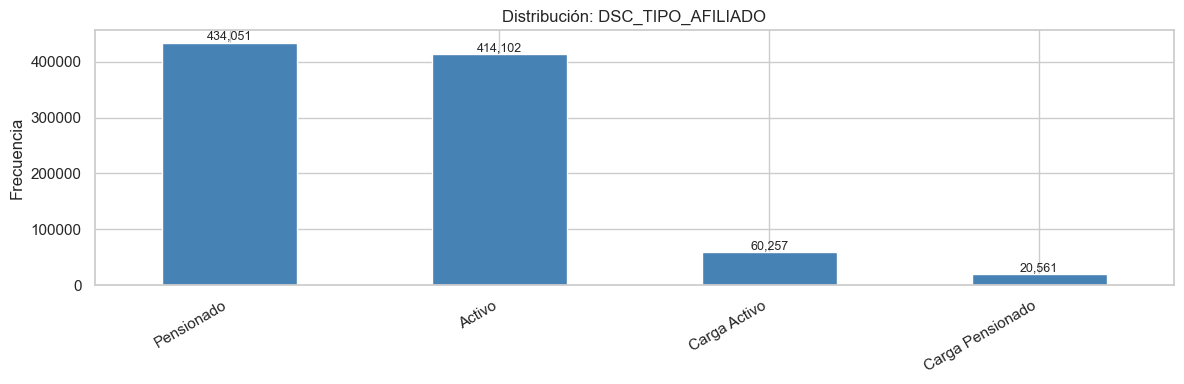

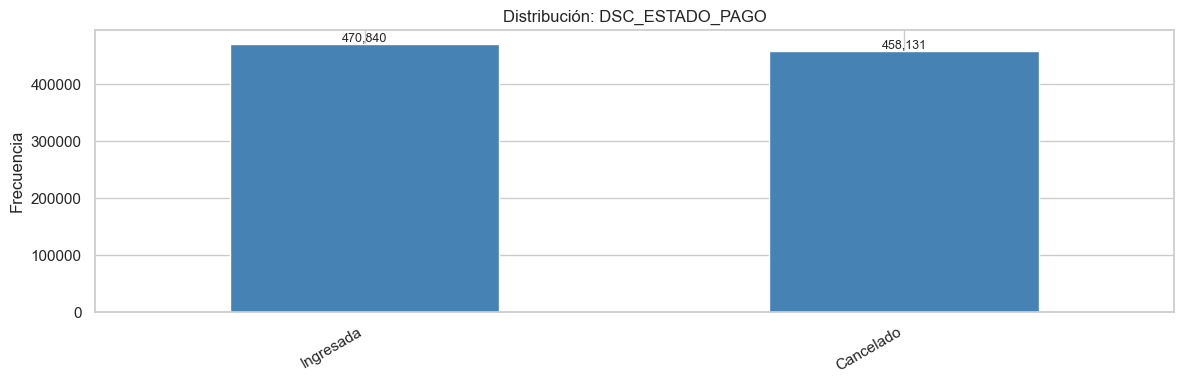

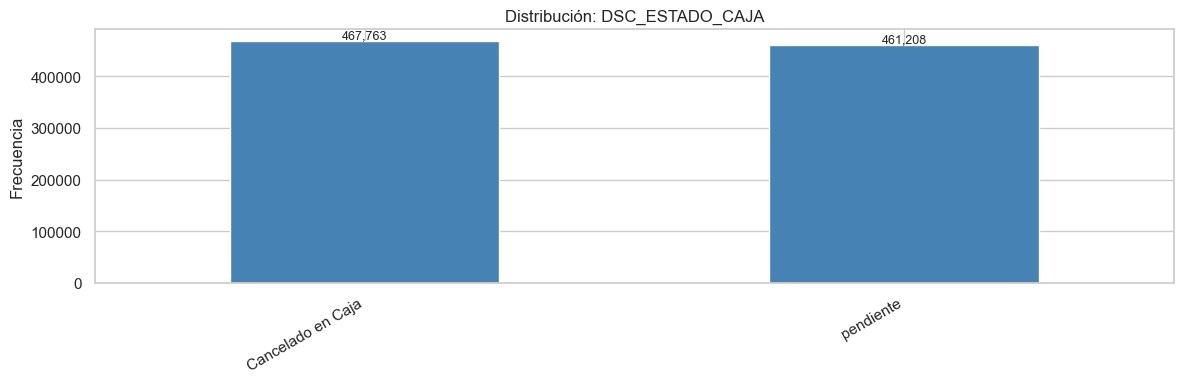

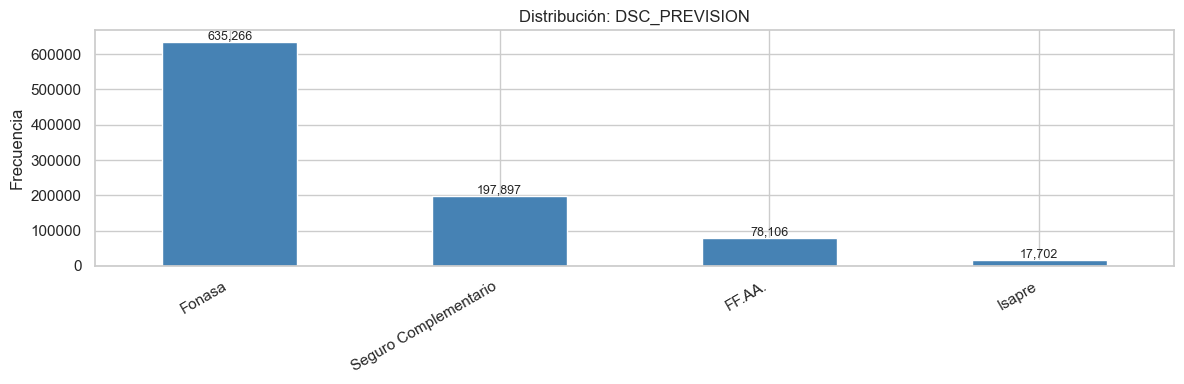

In [12]:
# Variables categóricas de baja cardinalidad — distribución de frecuencias
cat_baja_card = [c for c in col_categoricas if df[c].nunique() <= 20]

for col in cat_baja_card:
    fig, ax = plt.subplots(figsize=(12, 4))
    vc = df[col].value_counts()
    vc.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(f'Distribución: {col}', fontsize=12)
    ax.set_xlabel('')
    ax.set_ylabel('Frecuencia')
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height()):,}', 
                    (p.get_x() + p.get_width() / 2, p.get_height()),
                    ha='center', va='bottom', fontsize=9)
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()

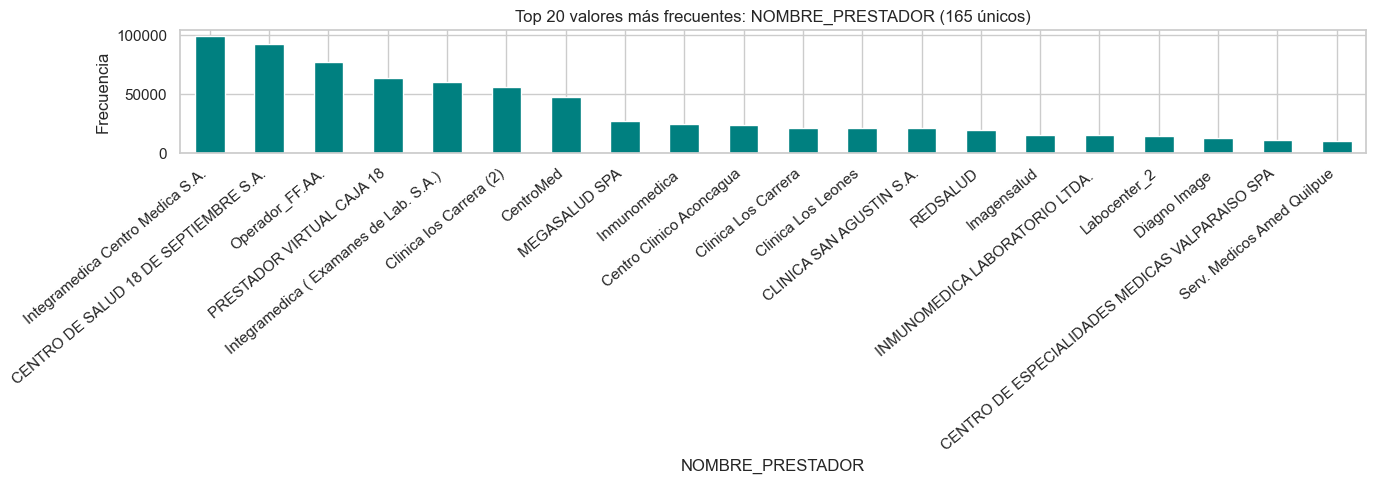

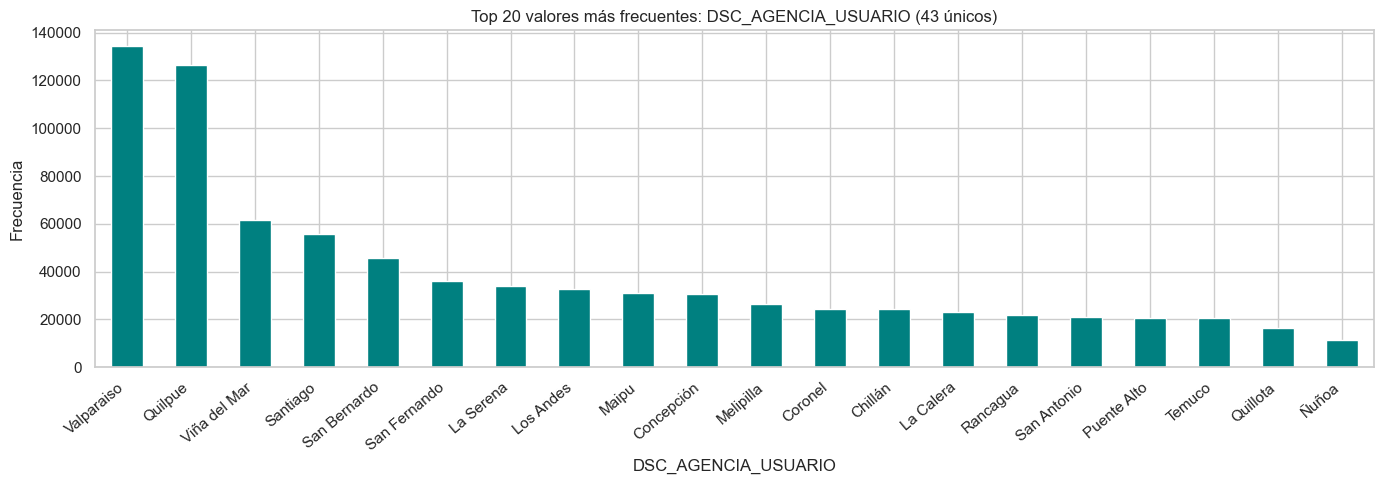

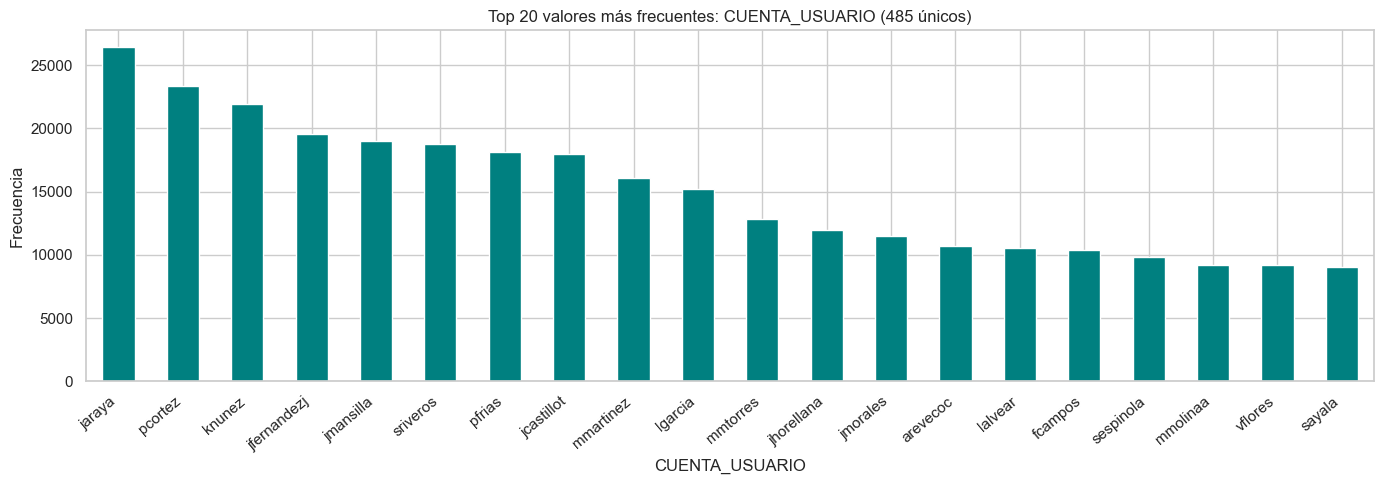

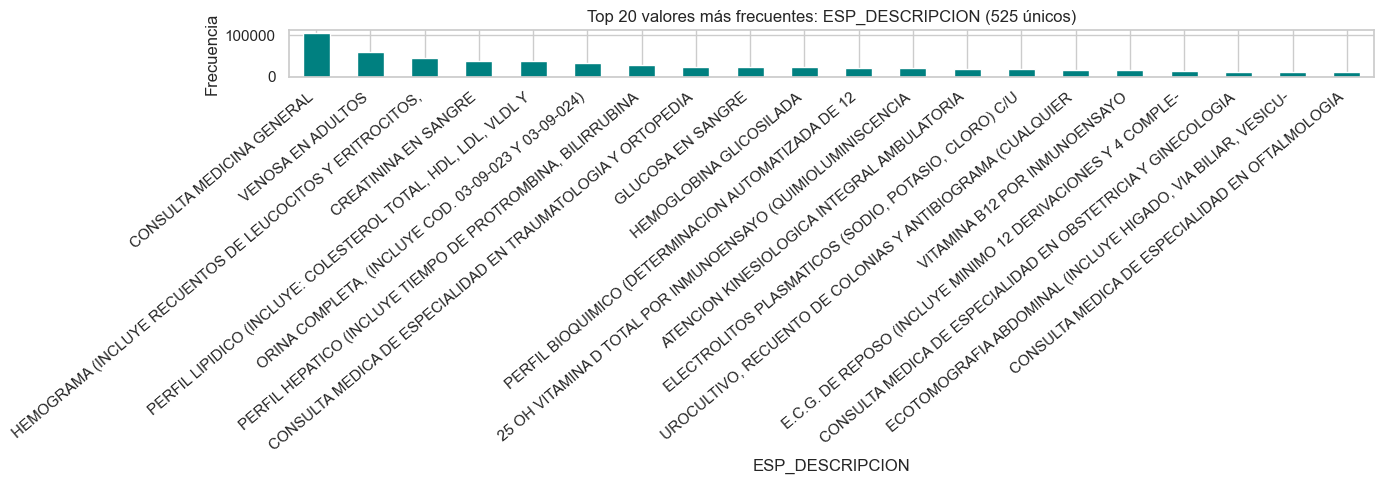

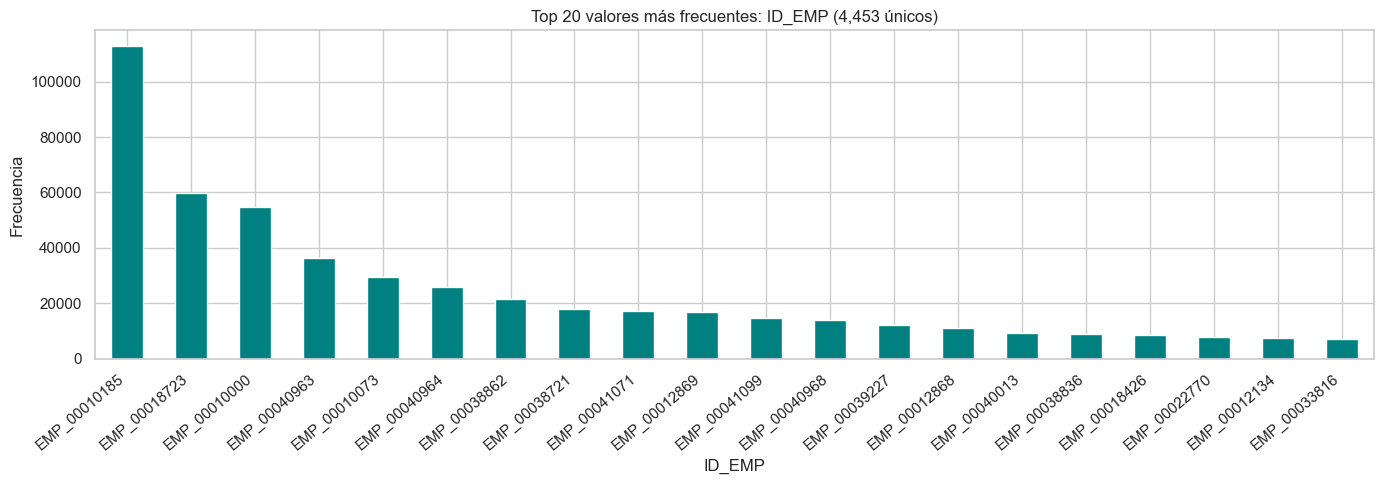

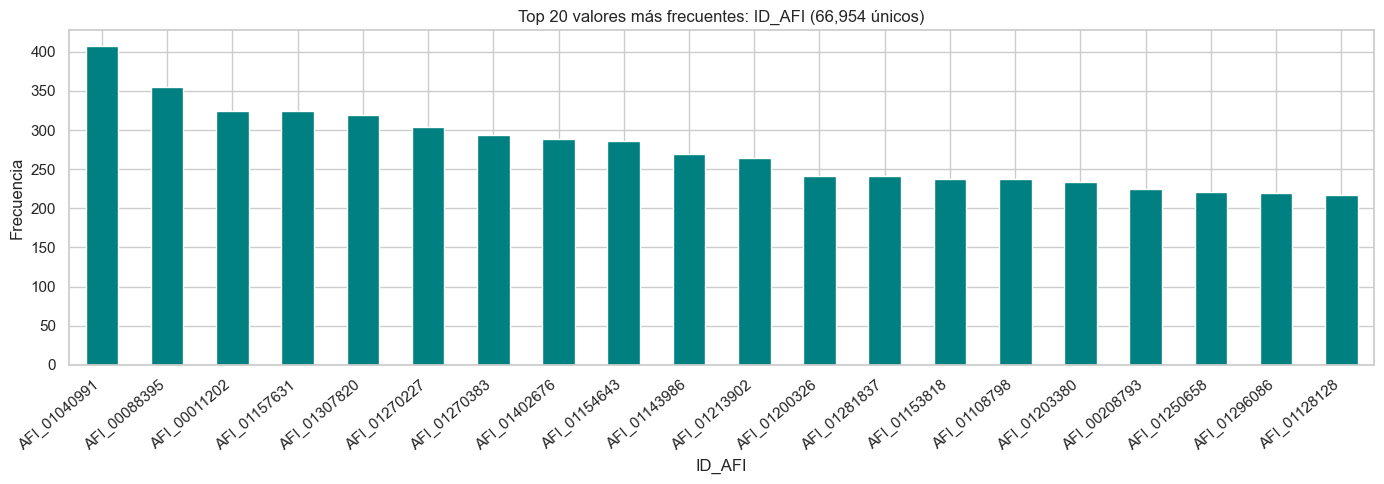

In [13]:
# Top 20 para variables de alta cardinalidad
cat_alta_card = [c for c in col_categoricas if df[c].nunique() > 20]

for col in cat_alta_card:
    fig, ax = plt.subplots(figsize=(14, 5))
    df[col].value_counts().head(20).plot(kind='bar', ax=ax, color='teal', edgecolor='white')
    ax.set_title(f'Top 20 valores más frecuentes: {col} ({df[col].nunique():,} únicos)', fontsize=12)
    ax.set_ylabel('Frecuencia')
    plt.xticks(rotation=40, ha='right')
    plt.tight_layout()
    plt.show()

## 7. Análisis de Variables Numéricas — Distribuciones

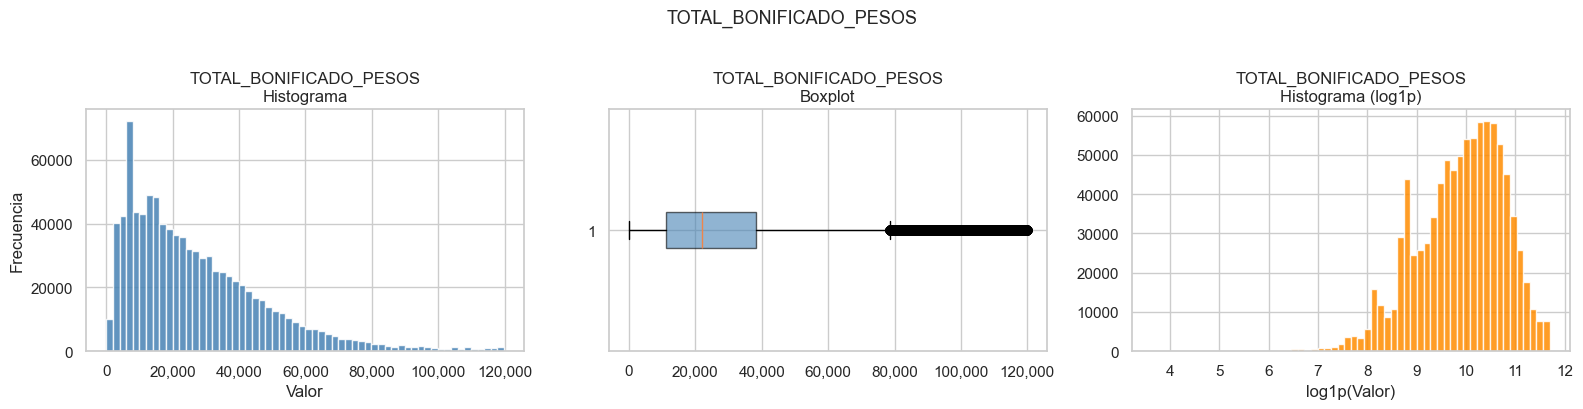

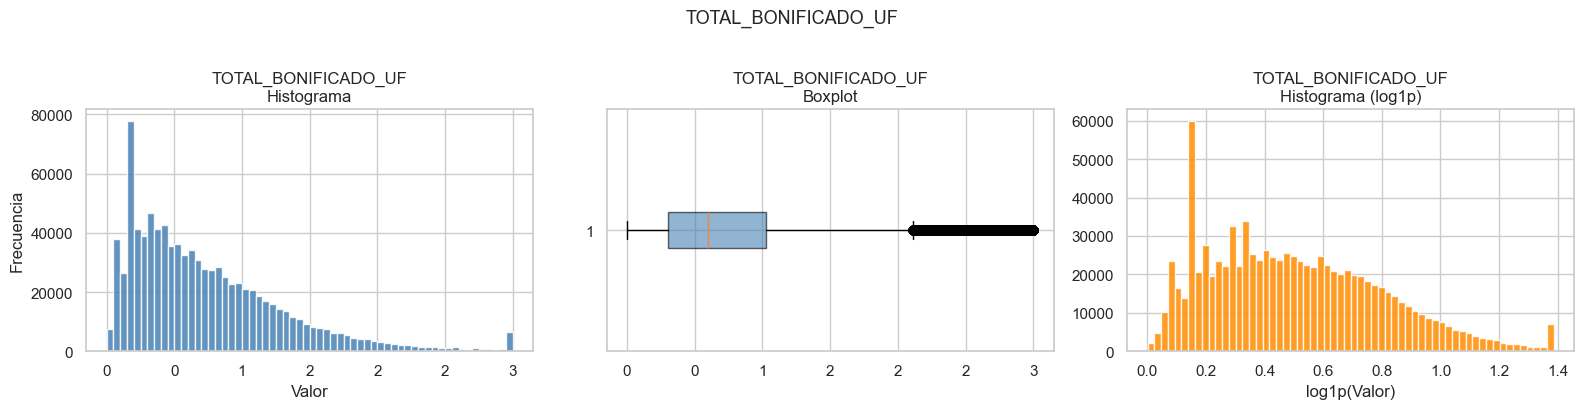

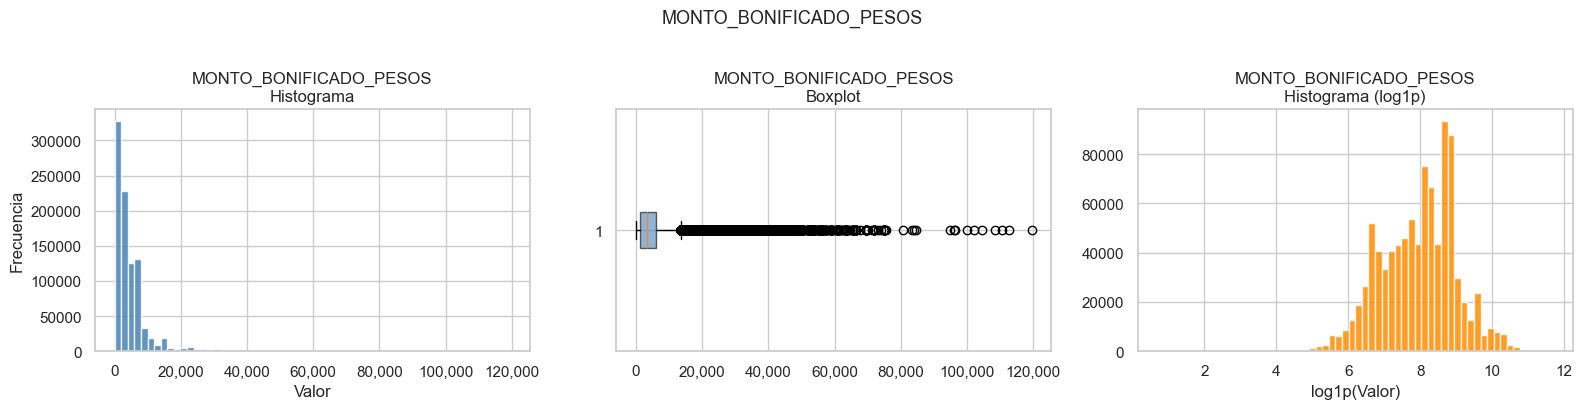

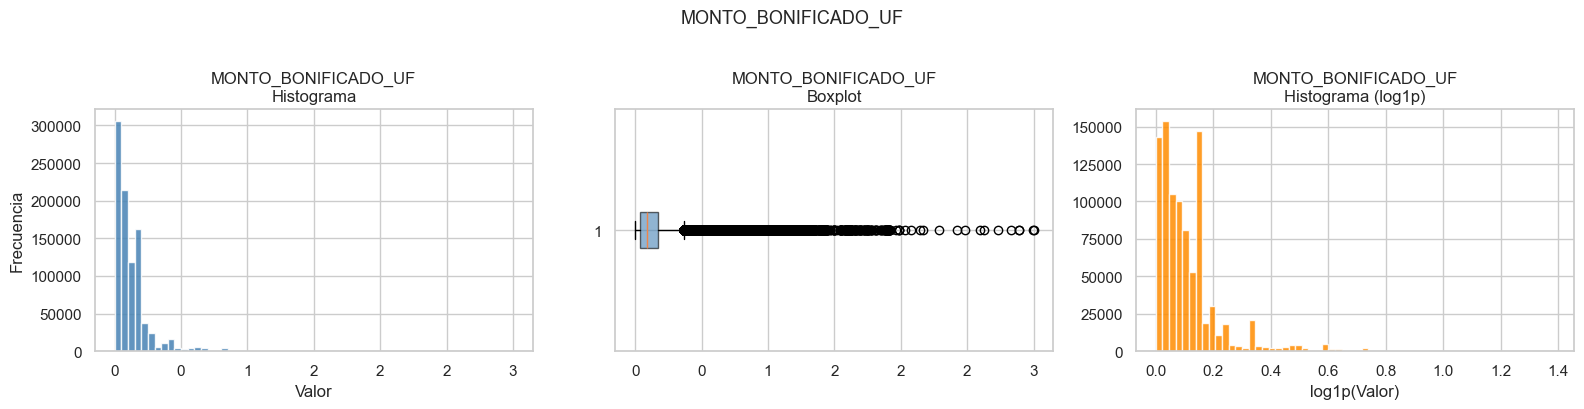

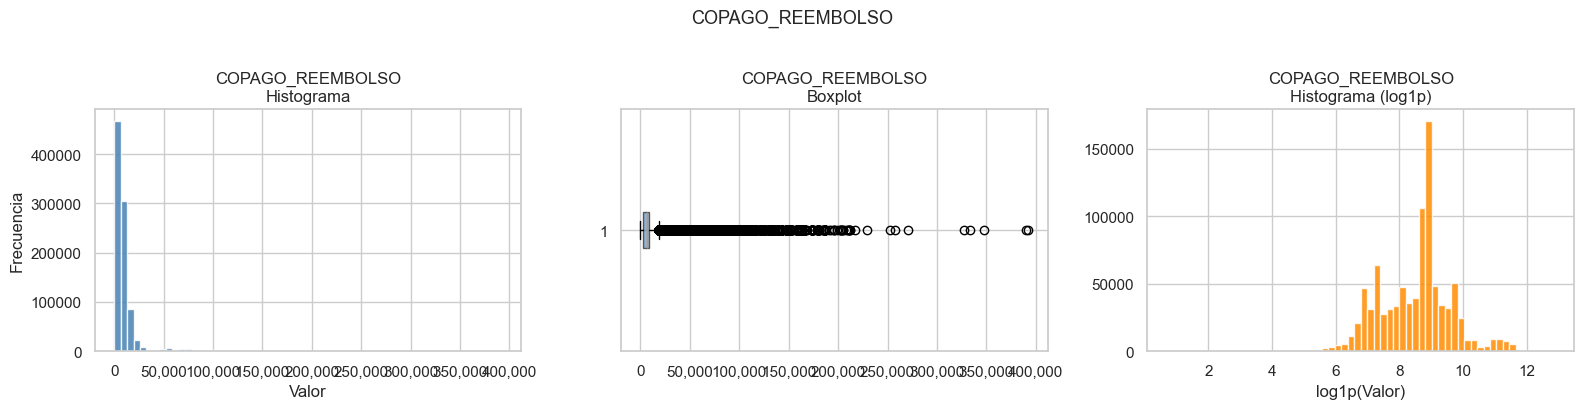

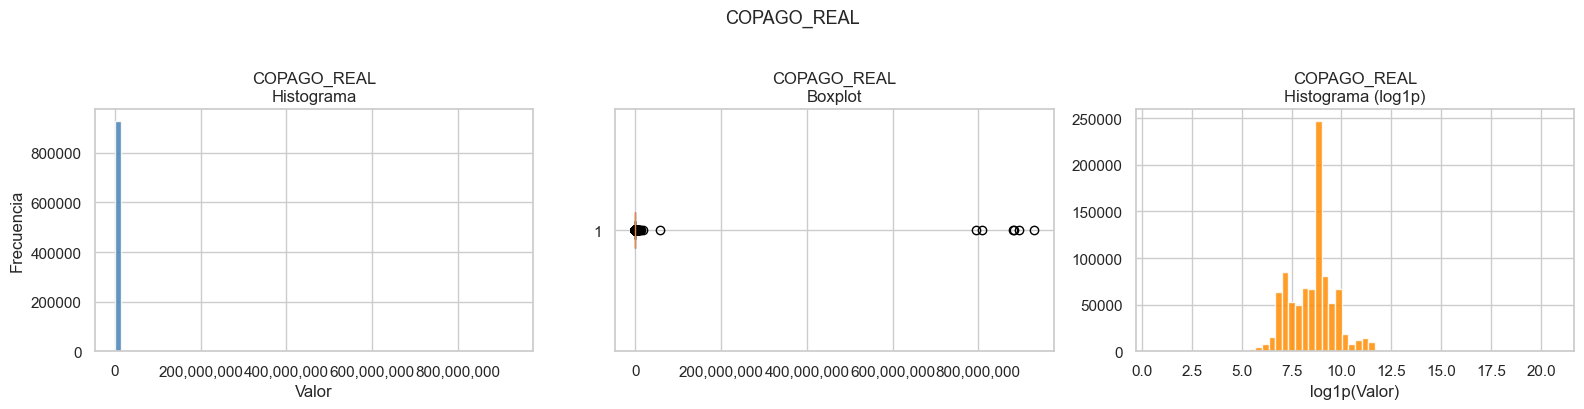

In [14]:
# Columnas de montos/importes para análisis de distribución
cols_montos = ['TOTAL_BONIFICADO_PESOS', 'TOTAL_BONIFICADO_UF',
               'MONTO_BONIFICADO_PESOS', 'MONTO_BONIFICADO_UF',
               'COPAGO_REEMBOLSO', 'COPAGO_REAL']
cols_montos = [c for c in cols_montos if c in df.columns]

for col in cols_montos:
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    datos = df[col].dropna()

    # Histograma
    axes[0].hist(datos, bins=60, color='steelblue', edgecolor='white', alpha=0.85)
    axes[0].set_title(f'{col}\nHistograma')
    axes[0].set_xlabel('Valor')
    axes[0].set_ylabel('Frecuencia')
    axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

    # Boxplot
    axes[1].boxplot(datos, vert=False, patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.6))
    axes[1].set_title(f'{col}\nBoxplot')
    axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

    # Log-escala si hay valores > 0
    datos_pos = datos[datos > 0]
    if len(datos_pos) > 0:
        axes[2].hist(np.log1p(datos_pos), bins=60, color='darkorange', edgecolor='white', alpha=0.85)
        axes[2].set_title(f'{col}\nHistograma (log1p)')
        axes[2].set_xlabel('log1p(Valor)')

    plt.suptitle(col, fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()

## 8. Análisis Temporal

In [15]:
# Cobertura temporal del dataset
for col_fecha in col_fechas:
    print(f'{col_fecha}:')
    print(f'  Mínimo: {df[col_fecha].min()}')
    print(f'  Máximo: {df[col_fecha].max()}')
    print(f'  Rango : {(df[col_fecha].max() - df[col_fecha].min()).days} días')
    print()

FECHA_BONO:
  Mínimo: 2021-10-25 00:00:00
  Máximo: 2026-04-17 00:00:00
  Rango : 1635 días

FECHA_MOVIMIENTO:
  Mínimo: 2022-01-03 09:05:07
  Máximo: 2026-04-17 16:10:37
  Rango : 1565 días



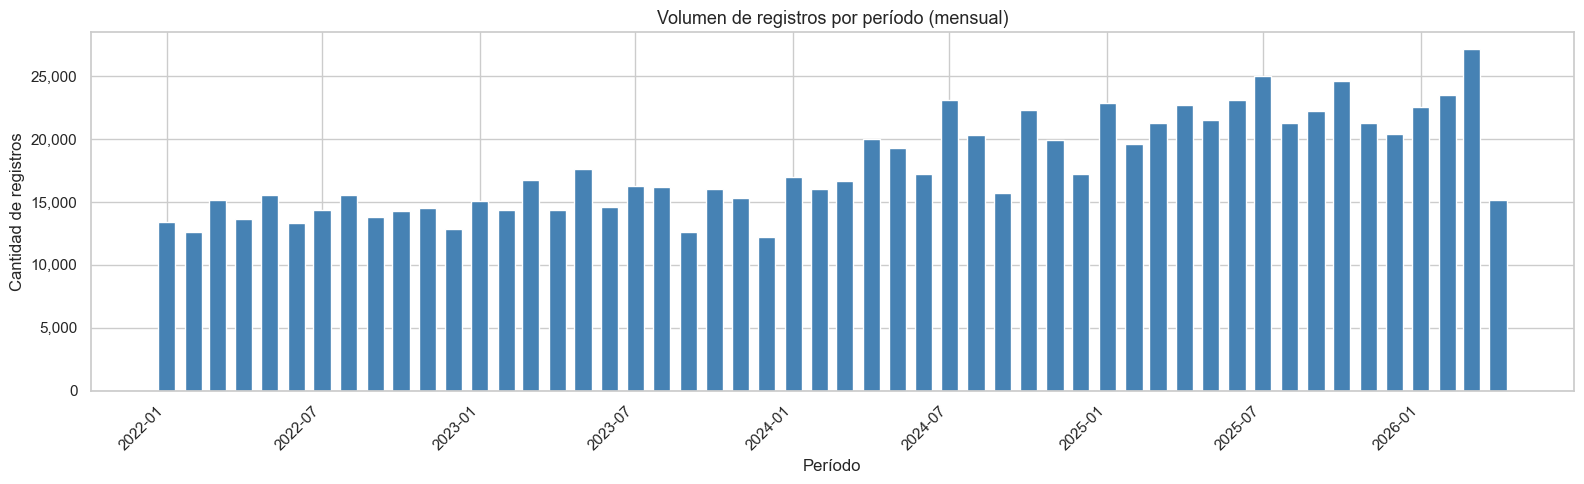

FECHA_PERIODO  Registros
   2022-01-01      13416
   2022-02-01      12616
   2022-03-01      15131
   2022-04-01      13610
   2022-05-01      15536
   2022-06-01      13299
   2022-07-01      14346
   2022-08-01      15514
   2022-09-01      13808
   2022-10-01      14255
   2022-11-01      14516
   2022-12-01      12822
   2023-01-01      15052
   2023-02-01      14389
   2023-03-01      16752
   2023-04-01      14321
   2023-05-01      17578
   2023-06-01      14610
   2023-07-01      16229
   2023-08-01      16166
   2023-09-01      12632
   2023-10-01      16037
   2023-11-01      15289
   2023-12-01      12224
   2024-01-01      16963
   2024-02-01      16036
   2024-03-01      16635
   2024-04-01      19957
   2024-05-01      19293
   2024-06-01      17202
   2024-07-01      23078
   2024-08-01      20347
   2024-09-01      15681
   2024-10-01      22300
   2024-11-01      19925
   2024-12-01      17232
   2025-01-01      22820
   2025-02-01      19626
   2025-03-01      21255


In [16]:
# Volumen mensual de registros (usando PERIODO)
if 'PERIODO' in df.columns:
    periodo_str = df['PERIODO'].astype(str)
    df['ANIO']  = periodo_str.str[:4].astype(int)
    df['MES']   = periodo_str.str[4:6].astype(int)
    df['FECHA_PERIODO'] = pd.to_datetime(df['PERIODO'].astype(str), format='%Y%m')

    vol_mensual = df.groupby('FECHA_PERIODO').size().reset_index(name='Registros')

    fig, ax = plt.subplots(figsize=(16, 5))
    ax.bar(vol_mensual['FECHA_PERIODO'], vol_mensual['Registros'], color='steelblue', width=20)
    ax.set_title('Volumen de registros por período (mensual)', fontsize=13)
    ax.set_xlabel('Período')
    ax.set_ylabel('Cantidad de registros')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    print(vol_mensual.sort_values('FECHA_PERIODO').to_string(index=False))

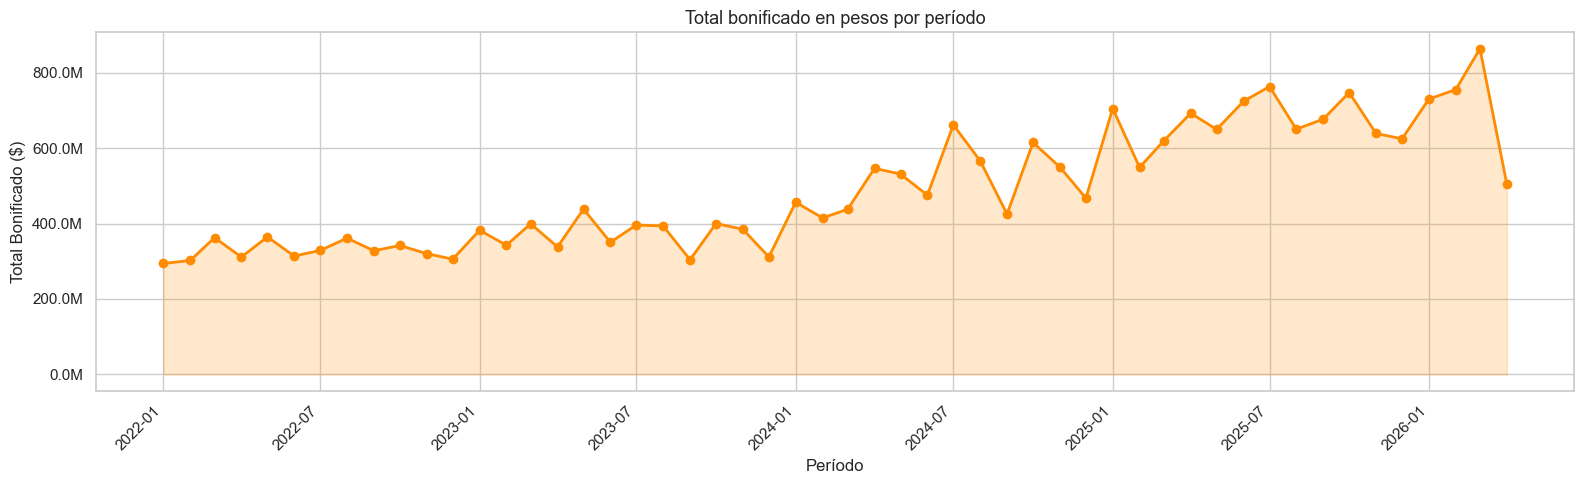

In [17]:
# Monto total bonificado mensual (pesos)
if 'TOTAL_BONIFICADO_PESOS' in df.columns and 'FECHA_PERIODO' in df.columns:
    monto_mensual = df.groupby('FECHA_PERIODO')['TOTAL_BONIFICADO_PESOS'].sum().reset_index()

    fig, ax = plt.subplots(figsize=(16, 5))
    ax.plot(monto_mensual['FECHA_PERIODO'], monto_mensual['TOTAL_BONIFICADO_PESOS'],
            marker='o', color='darkorange', linewidth=2)
    ax.fill_between(monto_mensual['FECHA_PERIODO'], monto_mensual['TOTAL_BONIFICADO_PESOS'],
                    alpha=0.2, color='darkorange')
    ax.set_title('Total bonificado en pesos por período', fontsize=13)
    ax.set_xlabel('Período')
    ax.set_ylabel('Total Bonificado ($)')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:,.1f}M'))
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

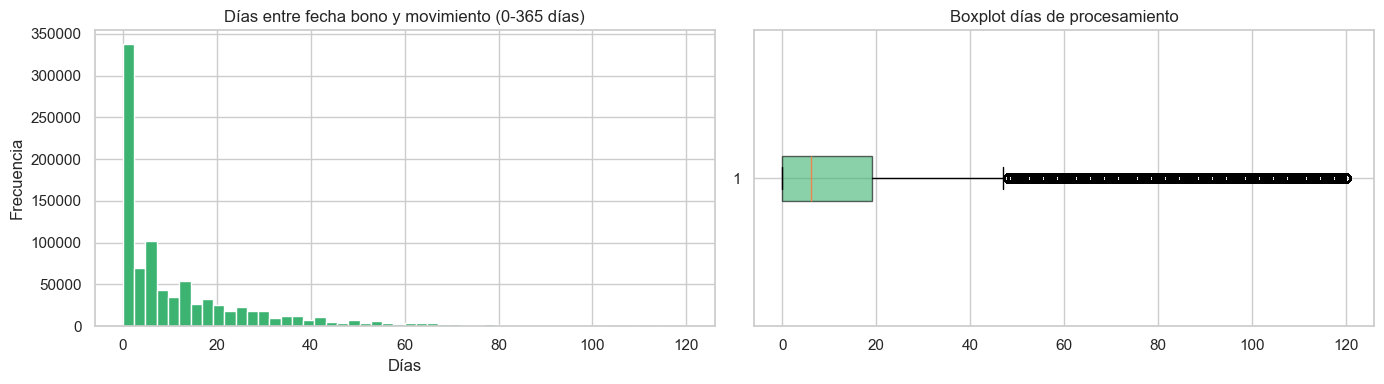

Estadísticas días de procesamiento (válidos 0-365):
count   928,971.0000
mean         13.7905
std          19.5145
min           0.0000
25%           0.0000
50%           6.0000
75%          19.0000
max         120.0000

Registros con fecha_movimiento < fecha_bono: 0 (0.00%)


In [18]:
# Días entre fecha de bono y fecha de movimiento (lag de procesamiento)
if 'FECHA_BONO' in df.columns and 'FECHA_MOVIMIENTO' in df.columns:
    df['DIAS_PROCESAMIENTO'] = (df['FECHA_MOVIMIENTO'] - df['FECHA_BONO']).dt.days

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    datos_lag = df['DIAS_PROCESAMIENTO'].dropna()
    datos_lag_valid = datos_lag[(datos_lag >= 0) & (datos_lag <= 365)]

    axes[0].hist(datos_lag_valid, bins=50, color='mediumseagreen', edgecolor='white')
    axes[0].set_title('Días entre fecha bono y movimiento (0-365 días)')
    axes[0].set_xlabel('Días')
    axes[0].set_ylabel('Frecuencia')

    axes[1].boxplot(datos_lag_valid, vert=False, patch_artist=True,
                    boxprops=dict(facecolor='mediumseagreen', alpha=0.6))
    axes[1].set_title('Boxplot días de procesamiento')

    plt.tight_layout()
    plt.show()

    print(f'Estadísticas días de procesamiento (válidos 0-365):')
    print(datos_lag_valid.describe().to_string())
    negativos = (datos_lag < 0).sum()
    print(f'\nRegistros con fecha_movimiento < fecha_bono: {negativos:,} ({negativos/len(df)*100:.2f}%)')

## 9. Análisis por Variables Clave de Negocio

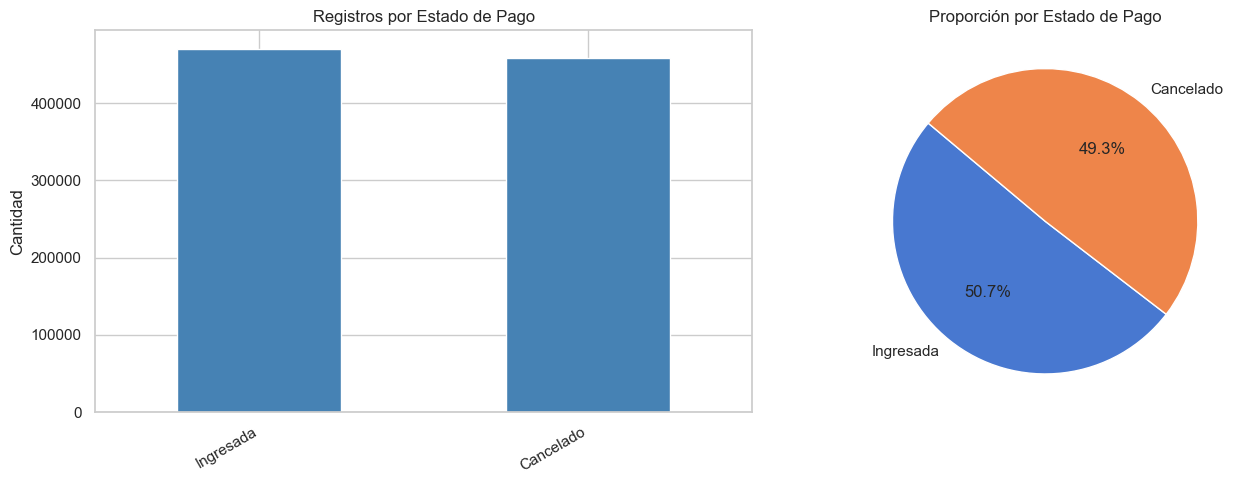

In [19]:
# Distribución por Estado de Pago
if 'DSC_ESTADO_PAGO' in df.columns:
    estado_pago = df['DSC_ESTADO_PAGO'].value_counts()

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    estado_pago.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
    axes[0].set_title('Registros por Estado de Pago')
    axes[0].set_xlabel('')
    axes[0].set_ylabel('Cantidad')
    plt.sca(axes[0])
    plt.xticks(rotation=30, ha='right')

    axes[1].pie(estado_pago, labels=estado_pago.index, autopct='%1.1f%%',
                startangle=140, colors=sns.color_palette('muted', len(estado_pago)))
    axes[1].set_title('Proporción por Estado de Pago')

    plt.tight_layout()
    plt.show()

,Promedio,Mediana,Total,Registros
DSC_TIPO_AFILIADO,,,,
Pensionado,"30,720.81","25,417.00","13,334,398,241.00","434,051.00"
Activo,"26,266.66","21,834.00","10,877,077,962.00","414,102.00"
Carga Activo,"13,403.11","11,018.00","807,631,097.00","60,257.00"
Carga Pensionado,"19,010.56","15,582.00","390,876,151.00","20,561.00"


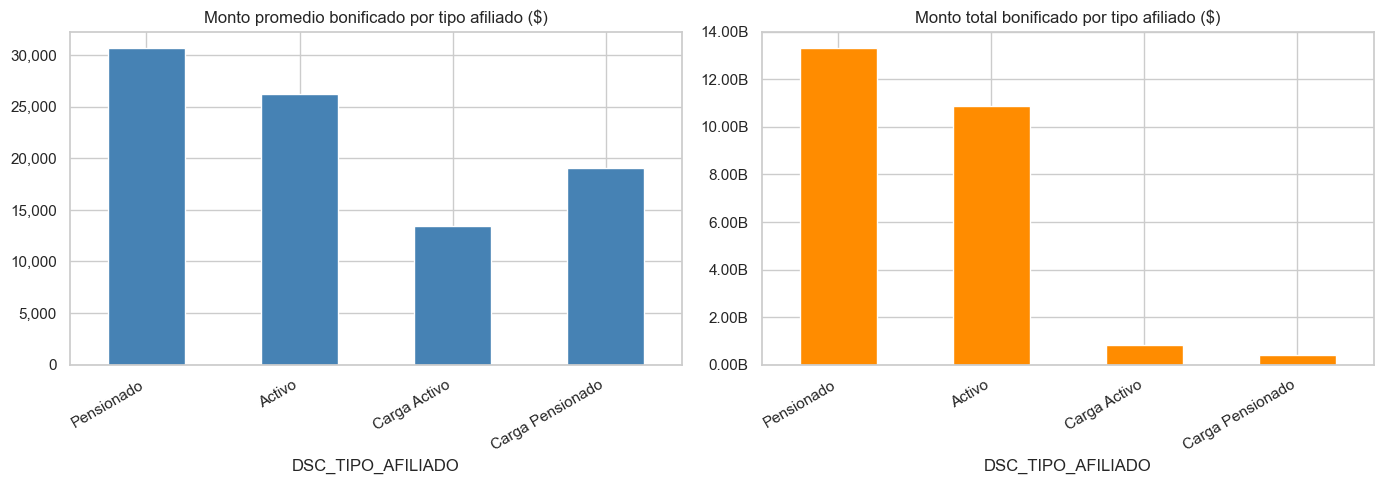

In [20]:
# Monto promedio bonificado por tipo de afiliado
if 'DSC_TIPO_AFILIADO' in df.columns and 'TOTAL_BONIFICADO_PESOS' in df.columns:
    monto_afiliado = df.groupby('DSC_TIPO_AFILIADO')['TOTAL_BONIFICADO_PESOS'].agg(['mean', 'median', 'sum', 'count'])
    monto_afiliado.columns = ['Promedio', 'Mediana', 'Total', 'Registros']
    monto_afiliado = monto_afiliado.sort_values('Total', ascending=False)

    display(monto_afiliado.style.format('{:,.2f}'))

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    monto_afiliado['Promedio'].plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
    axes[0].set_title('Monto promedio bonificado por tipo afiliado ($)')
    axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    plt.sca(axes[0]); plt.xticks(rotation=30, ha='right')

    monto_afiliado['Total'].plot(kind='bar', ax=axes[1], color='darkorange', edgecolor='white')
    axes[1].set_title('Monto total bonificado por tipo afiliado ($)')
    axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e9:,.2f}B'))
    plt.sca(axes[1]); plt.xticks(rotation=30, ha='right')

    plt.tight_layout()
    plt.show()

,Promedio,Total,Registros
DSC_PREVISION,,,
Fonasa,"28,001.40","17,788,338,387.00","635,266.00"
Seguro Complementario,"23,677.42","4,685,690,832.00","197,897.00"
FF.AA.,"33,682.67","2,630,818,348.00","78,106.00"
Isapre,"17,237.37","305,135,884.00","17,702.00"


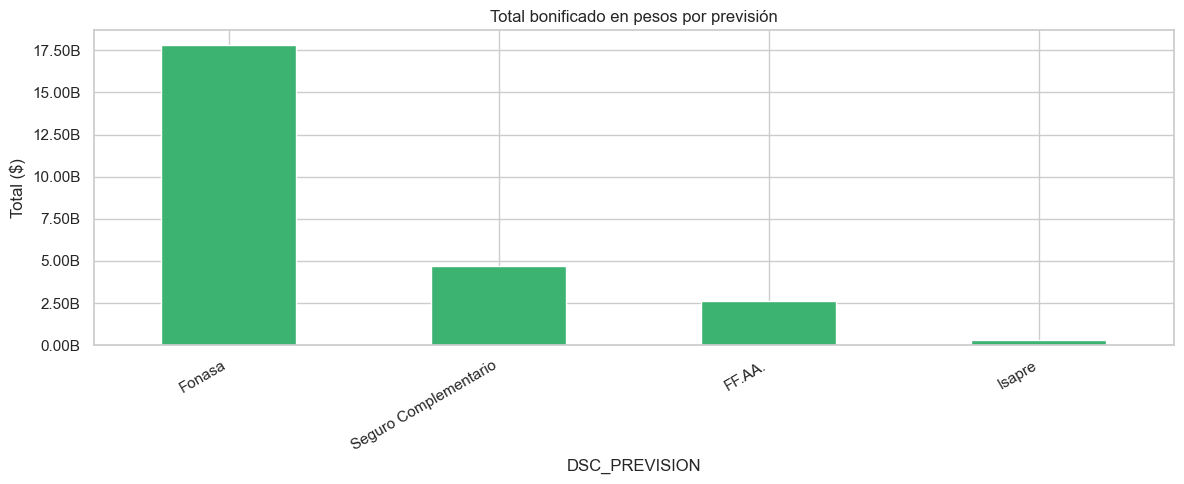

In [21]:
# Monto promedio bonificado por previsión
if 'DSC_PREVISION' in df.columns and 'TOTAL_BONIFICADO_PESOS' in df.columns:
    monto_prevision = df.groupby('DSC_PREVISION')['TOTAL_BONIFICADO_PESOS'].agg(['mean', 'sum', 'count'])
    monto_prevision.columns = ['Promedio', 'Total', 'Registros']
    monto_prevision = monto_prevision.sort_values('Total', ascending=False)

    display(monto_prevision.style.format('{:,.2f}'))

    fig, ax = plt.subplots(figsize=(12, 5))
    monto_prevision['Total'].plot(kind='bar', ax=ax, color='mediumseagreen', edgecolor='white')
    ax.set_title('Total bonificado en pesos por previsión')
    ax.set_ylabel('Total ($)')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e9:,.2f}B'))
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()

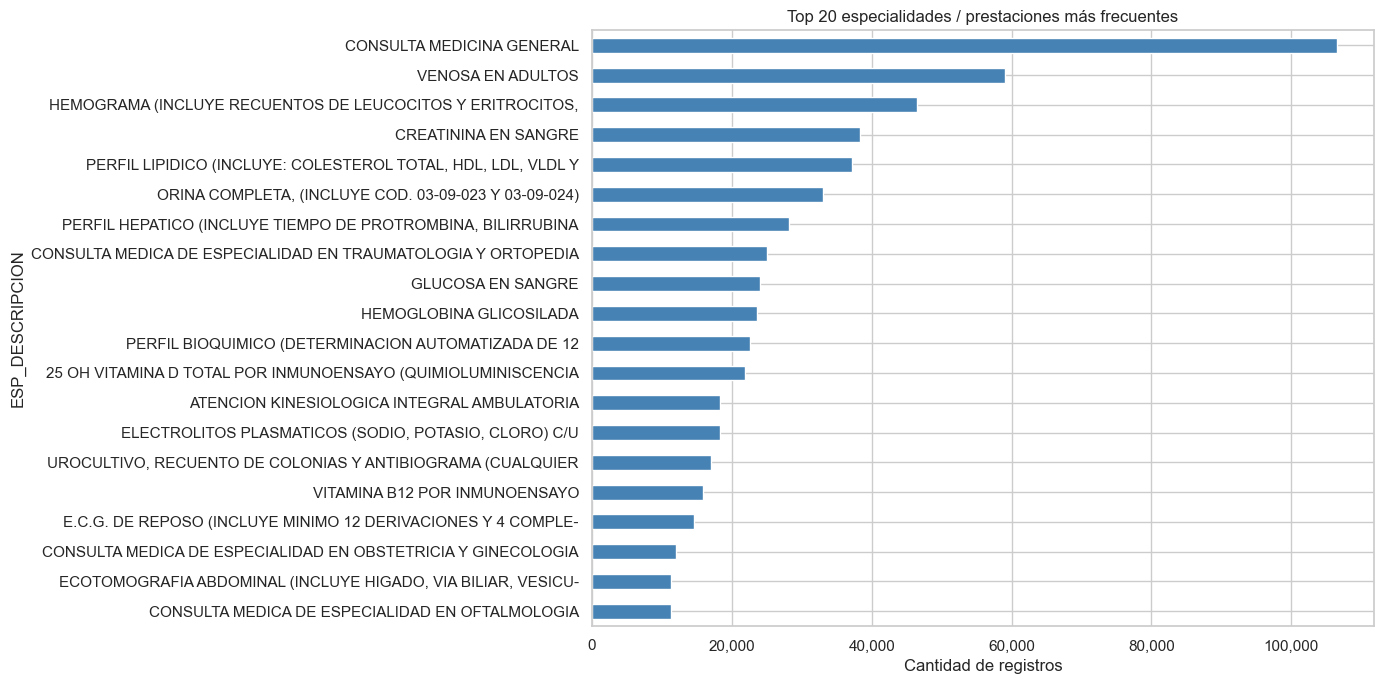

In [22]:
# Top 20 especialidades médicas más frecuentes
if 'ESP_DESCRIPCION' in df.columns:
    top_esp = df['ESP_DESCRIPCION'].value_counts().head(20)

    fig, ax = plt.subplots(figsize=(14, 7))
    top_esp.sort_values().plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
    ax.set_title('Top 20 especialidades / prestaciones más frecuentes', fontsize=12)
    ax.set_xlabel('Cantidad de registros')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    plt.tight_layout()
    plt.show()

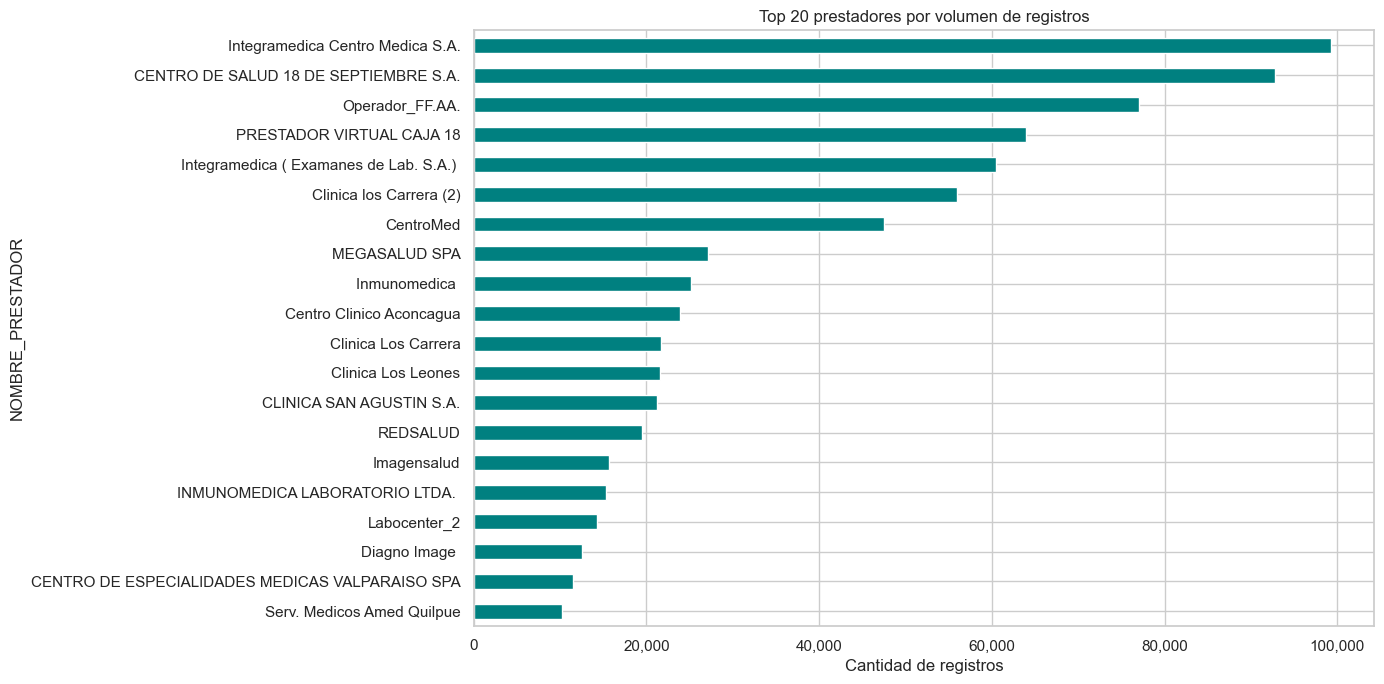

In [23]:
# Top 20 prestadores por volumen de registros
if 'NOMBRE_PRESTADOR' in df.columns:
    top_prestadores = df['NOMBRE_PRESTADOR'].value_counts().head(20)

    fig, ax = plt.subplots(figsize=(14, 7))
    top_prestadores.sort_values().plot(kind='barh', ax=ax, color='teal', edgecolor='white')
    ax.set_title('Top 20 prestadores por volumen de registros', fontsize=12)
    ax.set_xlabel('Cantidad de registros')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    plt.tight_layout()
    plt.show()

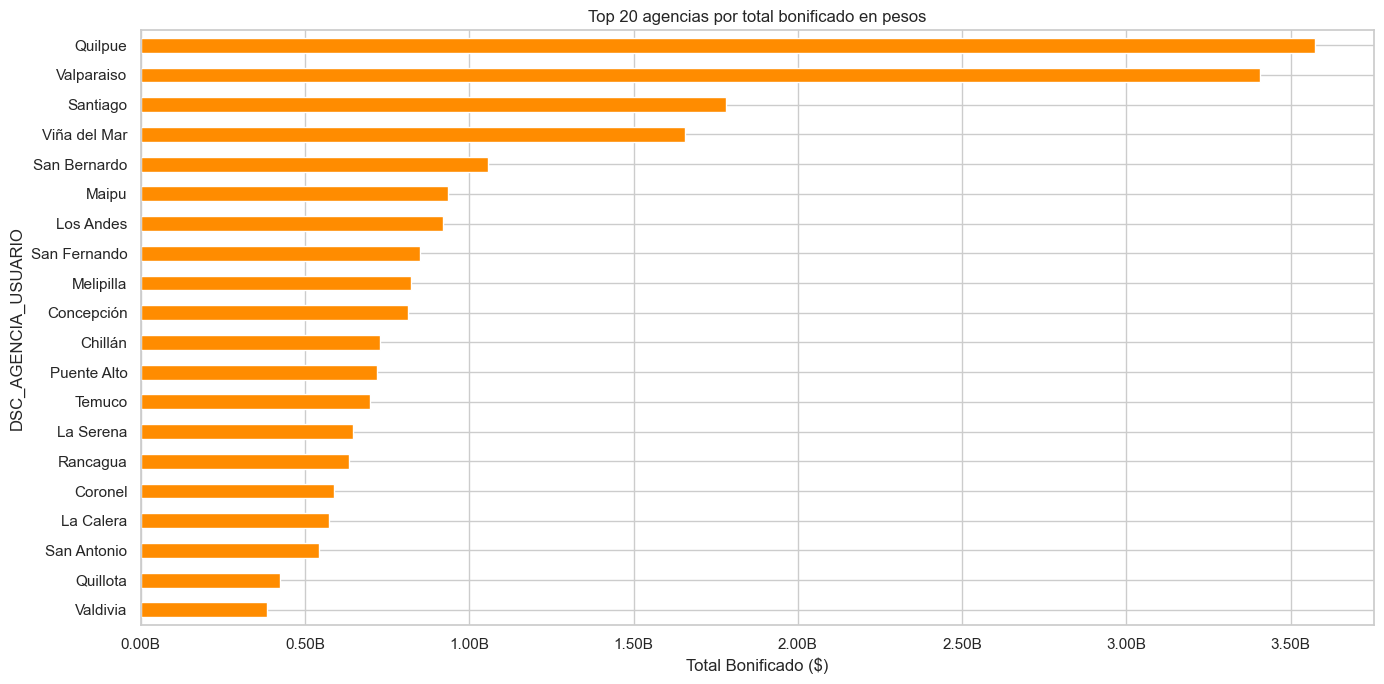

In [24]:
# Top 20 agencias por monto total bonificado
if 'DSC_AGENCIA_USUARIO' in df.columns and 'TOTAL_BONIFICADO_PESOS' in df.columns:
    agencia_monto = df.groupby('DSC_AGENCIA_USUARIO')['TOTAL_BONIFICADO_PESOS'].sum().sort_values(ascending=False).head(20)

    fig, ax = plt.subplots(figsize=(14, 7))
    agencia_monto.sort_values().plot(kind='barh', ax=ax, color='darkorange', edgecolor='white')
    ax.set_title('Top 20 agencias por total bonificado en pesos', fontsize=12)
    ax.set_xlabel('Total Bonificado ($)')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e9:,.2f}B'))
    plt.tight_layout()
    plt.show()

## 10. Análisis de Copago vs. Bonificación

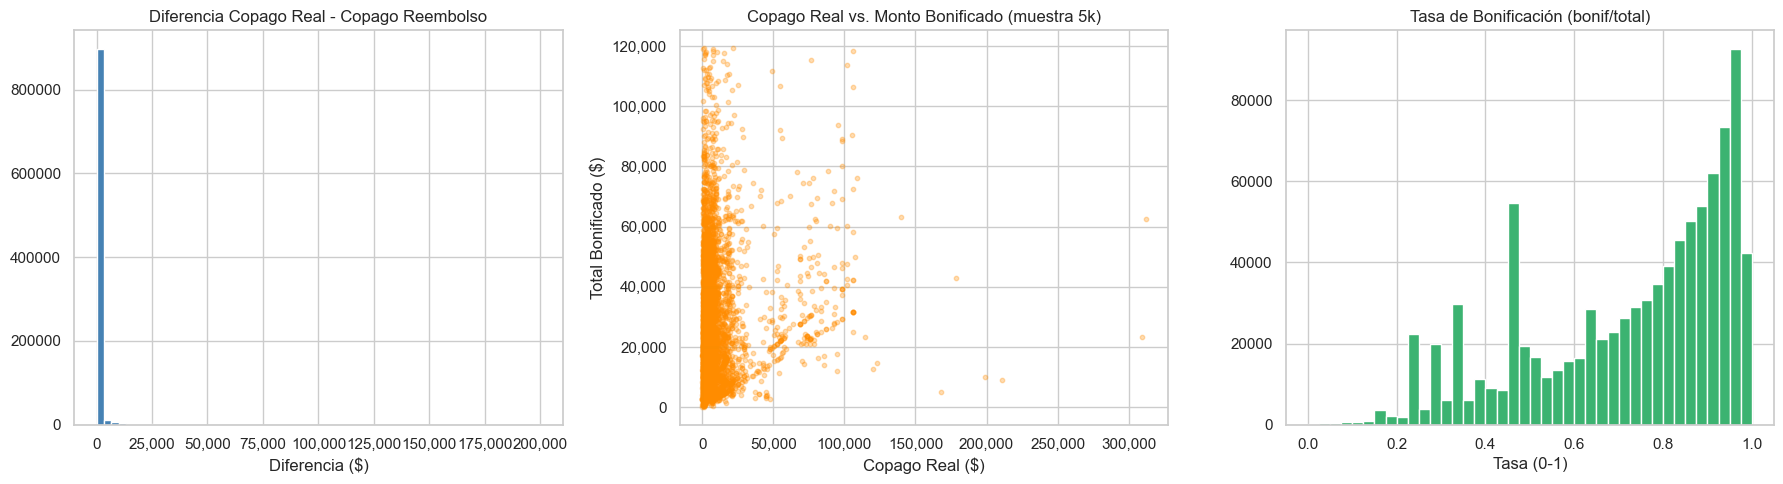

Diferencia copago — estadísticas:
count       928,971.0000
mean          6,998.8076
std       2,202,895.6747
min               0.0000
25%               0.0000
50%               0.0000
75%               0.0000
max     929,011,843.0000

Tasa de bonificación promedio: 0.7235


In [25]:
# Relación entre copago real y copago de reembolso
if 'COPAGO_REAL' in df.columns and 'COPAGO_REEMBOLSO' in df.columns:
    df['DIFERENCIA_COPAGO'] = df['COPAGO_REAL'] - df['COPAGO_REEMBOLSO']
    df['TASA_BONIFICACION'] = np.where(
        df['COPAGO_REAL'] > 0,
        df['TOTAL_BONIFICADO_PESOS'] / (df['TOTAL_BONIFICADO_PESOS'] + df['COPAGO_REAL']),
        np.nan
    )

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    df['DIFERENCIA_COPAGO'].clip(-50000, 200000).hist(bins=60, ax=axes[0], color='steelblue', edgecolor='white')
    axes[0].set_title('Diferencia Copago Real - Copago Reembolso')
    axes[0].set_xlabel('Diferencia ($)')
    axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

    sample = df[['COPAGO_REAL', 'TOTAL_BONIFICADO_PESOS']].dropna().sample(min(5000, len(df)), random_state=42)
    axes[1].scatter(sample['COPAGO_REAL'], sample['TOTAL_BONIFICADO_PESOS'], alpha=0.3, s=10, color='darkorange')
    axes[1].set_title('Copago Real vs. Monto Bonificado (muestra 5k)')
    axes[1].set_xlabel('Copago Real ($)')
    axes[1].set_ylabel('Total Bonificado ($)')
    axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

    df['TASA_BONIFICACION'].dropna().clip(0, 1).hist(bins=40, ax=axes[2], color='mediumseagreen', edgecolor='white')
    axes[2].set_title('Tasa de Bonificación (bonif/total)')
    axes[2].set_xlabel('Tasa (0-1)')

    plt.tight_layout()
    plt.show()

    print(f'Diferencia copago — estadísticas:')
    print(df['DIFERENCIA_COPAGO'].describe().to_string())
    print(f'\nTasa de bonificación promedio: {df["TASA_BONIFICACION"].mean():.4f}')

## 11. Análisis de Correlaciones

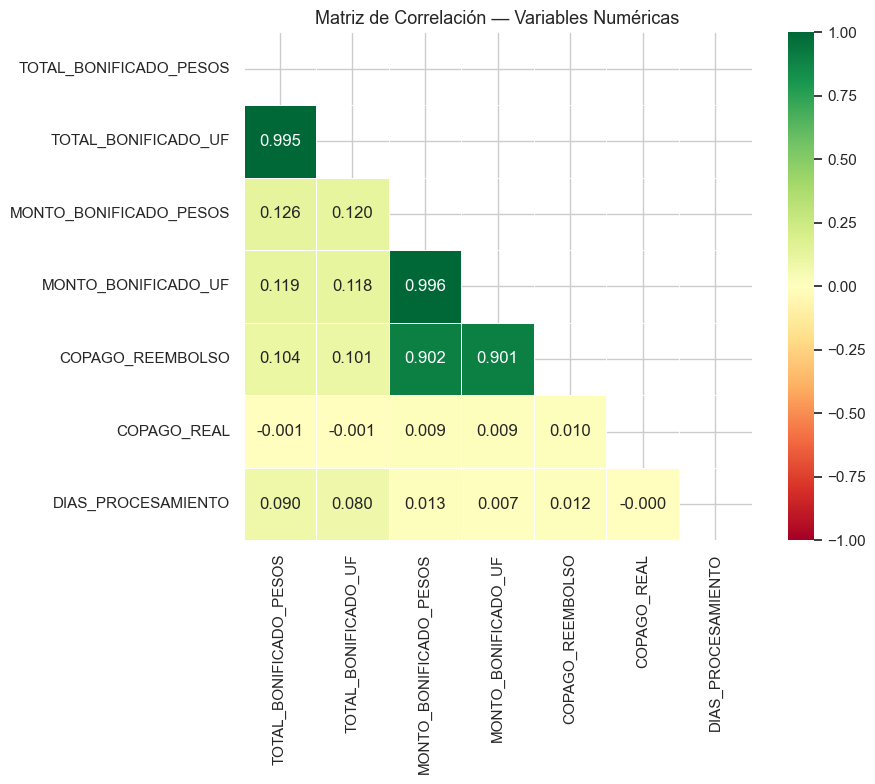

In [26]:
cols_corr = [c for c in ['TOTAL_BONIFICADO_PESOS', 'TOTAL_BONIFICADO_UF',
                          'MONTO_BONIFICADO_PESOS', 'MONTO_BONIFICADO_UF',
                          'COPAGO_REEMBOLSO', 'COPAGO_REAL',
                          'DIAS_PROCESAMIENTO'] if c in df.columns]

if len(cols_corr) > 1:
    corr_matrix = df[cols_corr].corr()

    fig, ax = plt.subplots(figsize=(10, 8))
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    sns.heatmap(
        corr_matrix, mask=mask, annot=True, fmt='.3f',
        cmap='RdYlGn', center=0, vmin=-1, vmax=1,
        square=True, linewidths=0.5, ax=ax
    )
    ax.set_title('Matriz de Correlación — Variables Numéricas', fontsize=13)
    plt.tight_layout()
    plt.show()

## 12. Detección de Outliers

In [27]:
def detectar_outliers_iqr(serie, nombre):
    Q1 = serie.quantile(0.25)
    Q3 = serie.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = serie[(serie < lower) | (serie > upper)]
    return {
        'Columna': nombre,
        'Q1': Q1, 'Q3': Q3, 'IQR': IQR,
        'Límite inferior': lower,
        'Límite superior': upper,
        'N° outliers': len(outliers),
        '% outliers': round(len(outliers) / len(serie) * 100, 2)
    }

cols_outlier = [c for c in ['TOTAL_BONIFICADO_PESOS', 'MONTO_BONIFICADO_PESOS',
                             'COPAGO_REEMBOLSO', 'COPAGO_REAL',
                             'DIAS_PROCESAMIENTO'] if c in df.columns]

resumen_outliers = pd.DataFrame([detectar_outliers_iqr(df[c].dropna(), c) for c in cols_outlier])
print('=== Detección de Outliers (método IQR) ===')
display(resumen_outliers.set_index('Columna').style.format('{:,.2f}'))

=== Detección de Outliers (método IQR) ===


,Q1,Q3,IQR,Límite inferior,Límite superior,N° outliers,% outliers
Columna,,,,,,,
TOTAL_BONIFICADO_PESOS,"11,163.00","38,176.00","27,013.00","-29,356.50","78,695.50","28,132.00",3.03
MONTO_BONIFICADO_PESOS,"1,330.00","6,190.00","4,860.00","-5,960.00","13,480.00","58,962.00",6.35
COPAGO_REEMBOLSO,"2,120.00","8,690.00","6,570.00","-7,735.00","18,545.00","79,586.00",8.57
COPAGO_REAL,"2,120.00","9,310.00","7,190.00","-8,665.00","20,095.00","78,350.00",8.43
DIAS_PROCESAMIENTO,0.00,19.00,19.00,-28.50,47.50,"63,730.00",6.86


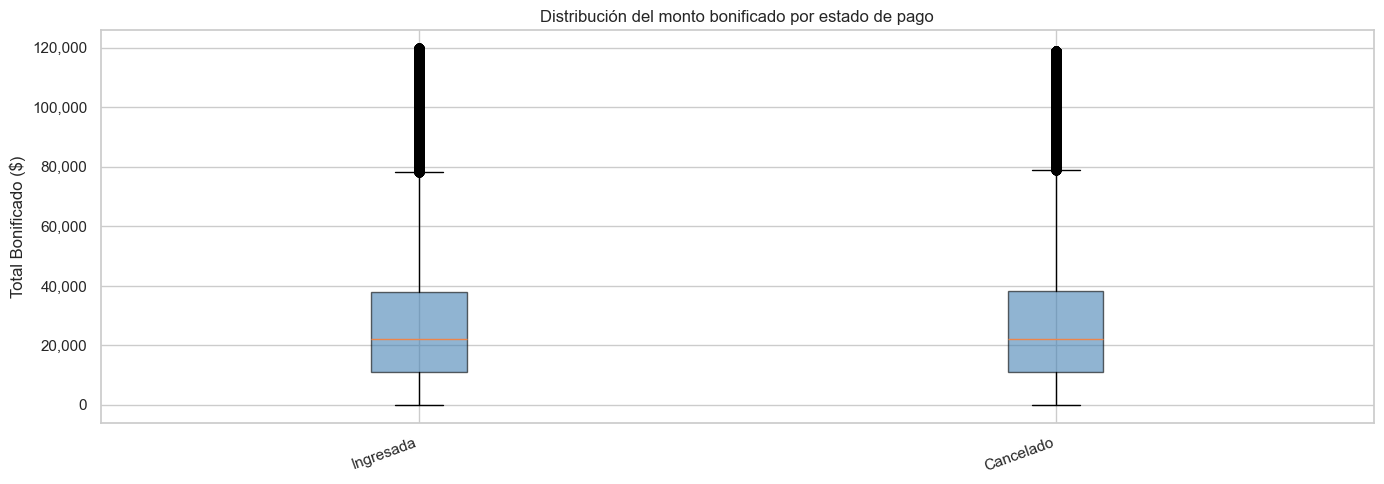

In [28]:
# Boxplots comparativos de montos por estado de pago
if 'DSC_ESTADO_PAGO' in df.columns and 'TOTAL_BONIFICADO_PESOS' in df.columns:
    fig, ax = plt.subplots(figsize=(14, 5))
    grupos = [df.loc[df['DSC_ESTADO_PAGO'] == estado, 'TOTAL_BONIFICADO_PESOS'].dropna()
              for estado in df['DSC_ESTADO_PAGO'].unique()]
    etiquetas = df['DSC_ESTADO_PAGO'].unique().tolist()
    ax.boxplot(grupos, labels=etiquetas, patch_artist=True,
               boxprops=dict(facecolor='steelblue', alpha=0.6))
    ax.set_title('Distribución del monto bonificado por estado de pago')
    ax.set_ylabel('Total Bonificado ($)')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    plt.xticks(rotation=20, ha='right')
    plt.tight_layout()
    plt.show()

## 13. Análisis de Duplicados

In [29]:
total_dups = df.duplicated().sum()
print(f'Filas completamente duplicadas: {total_dups:,} ({total_dups/len(df)*100:.4f}%)')

# Verificar unicidad de claves de negocio
for clave in [['FOLIO_REEMBOLSO'], ['FOLIO_BONO'], ['FOLIO_REEMBOLSO', 'FOLIO_BONO']]:
    cols_clave = [c for c in clave if c in df.columns]
    if cols_clave:
        dups = df.duplicated(subset=cols_clave).sum()
        print(f'Duplicados por {cols_clave}: {dups:,} ({dups/len(df)*100:.4f}%)')

Filas completamente duplicadas: 0 (0.0000%)
Duplicados por ['FOLIO_REEMBOLSO']: 928,699 (99.9707%)
Duplicados por ['FOLIO_BONO']: 395,195 (42.5412%)
Duplicados por ['FOLIO_REEMBOLSO', 'FOLIO_BONO']: 395,037 (42.5241%)


## 14. Análisis de Afiliadoes Únicos (Pseudonimizados)

Afiliados únicos (pseudonimizados): 66,954
Promedio de registros por afiliado: 13.87

Distribución de frecuencias por afiliado:
count   66,954.0000
mean        13.8748
std         18.1997
min          1.0000
25%          3.0000
50%          8.0000
75%         18.0000
max        407.0000


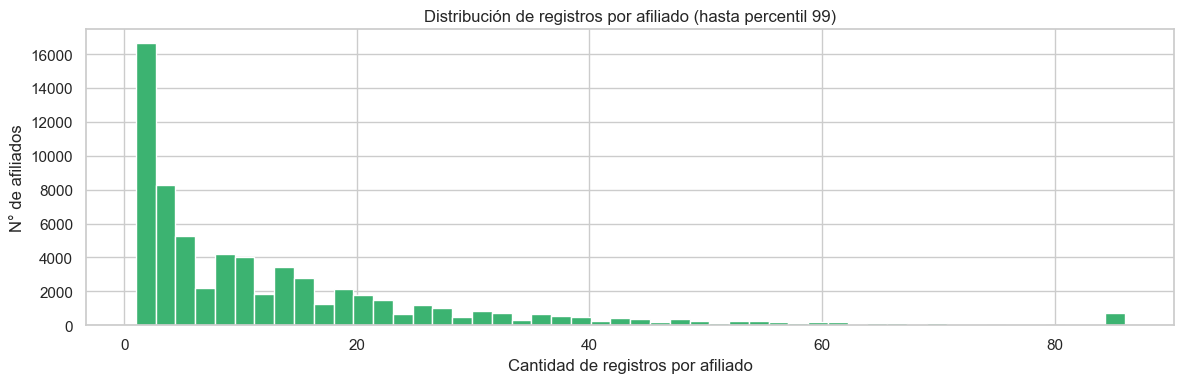


Empleadores únicos (pseudonimizados): 4,453


In [30]:
if 'ID_AFI' in df.columns:
    n_afiliados = df['ID_AFI'].nunique()
    print(f'Afiliados únicos (pseudonimizados): {n_afiliados:,}')
    print(f'Promedio de registros por afiliado: {len(df)/n_afiliados:.2f}')

    recuento_afi = df['ID_AFI'].value_counts()
    print(f'\nDistribución de frecuencias por afiliado:')
    print(recuento_afi.describe().to_string())

    fig, ax = plt.subplots(figsize=(12, 4))
    recuento_afi.clip(upper=recuento_afi.quantile(0.99)).hist(
        bins=50, ax=ax, color='mediumseagreen', edgecolor='white'
    )
    ax.set_title('Distribución de registros por afiliado (hasta percentil 99)')
    ax.set_xlabel('Cantidad de registros por afiliado')
    ax.set_ylabel('N° de afiliados')
    plt.tight_layout()
    plt.show()

if 'ID_EMP' in df.columns:
    n_emp = df['ID_EMP'].nunique()
    print(f'\nEmpleadores únicos (pseudonimizados): {n_emp:,}')

## 15. Resumen Ejecutivo

In [31]:
print('=' * 65)
print('         RESUMEN EJECUTIVO — EDA REEMBOLSO MÉDICO BNF')
print('=' * 65)

print(f'\n[VOLUMEN]')
print(f'  Total registros     : {len(df):,}')
print(f'  Total columnas      : {df.shape[1]}')

if 'FECHA_PERIODO' in df.columns:
    print(f'  Rango temporal      : {df["FECHA_PERIODO"].min().strftime("%Y-%m")} → {df["FECHA_PERIODO"].max().strftime("%Y-%m")}')

if 'ID_AFI' in df.columns:
    print(f'  Afiliados únicos    : {df["ID_AFI"].nunique():,}')

if 'NOMBRE_PRESTADOR' in df.columns:
    print(f'  Prestadores únicos  : {df["NOMBRE_PRESTADOR"].nunique():,}')

print(f'\n[MONTOS GLOBALES]')
for col in ['TOTAL_BONIFICADO_PESOS', 'COPAGO_REAL']:
    if col in df.columns:
        print(f'  {col}:')
        print(f'    Total   : ${df[col].sum():>20,.0f}')
        print(f'    Promedio: ${df[col].mean():>20,.2f}')
        print(f'    Mediana : ${df[col].median():>20,.2f}')

print(f'\n[CALIDAD DE DATOS]')
pct_nulos_total = df.isnull().sum().sum() / (len(df) * df.shape[1]) * 100
print(f'  Tasa de nulidad global: {pct_nulos_total:.4f}%')
print(f'  Duplicados exactos    : {df.duplicated().sum():,}')

print(f'\n[VARIABLES CATEGÓRICAS CLAVE]')
for col in ['DSC_ESTADO_PAGO', 'DSC_TIPO_AFILIADO', 'DSC_PREVISION']:
    if col in df.columns:
        top = df[col].value_counts().index[0]
        pct = df[col].value_counts().iloc[0] / len(df) * 100
        print(f'  {col}: "{top}" ({pct:.1f}%)')

print('\n' + '=' * 65)

         RESUMEN EJECUTIVO — EDA REEMBOLSO MÉDICO BNF

[VOLUMEN]
  Total registros     : 928,971
  Total columnas      : 36
  Rango temporal      : 2022-01 → 2026-04
  Afiliados únicos    : 66,954
  Prestadores únicos  : 165

[MONTOS GLOBALES]
  TOTAL_BONIFICADO_PESOS:
    Total   : $      25,409,983,451
    Promedio: $           27,352.83
    Mediana : $           22,098.00
  COPAGO_REAL:
    Total   : $      15,164,738,783
    Promedio: $           16,324.23
    Mediana : $            6,590.00

[CALIDAD DE DATOS]
  Tasa de nulidad global: 0.0001%
  Duplicados exactos    : 0

[VARIABLES CATEGÓRICAS CLAVE]
  DSC_ESTADO_PAGO: "Ingresada" (50.7%)
  DSC_TIPO_AFILIADO: "Pensionado" (46.7%)
  DSC_PREVISION: "Fonasa" (68.4%)

